# Moment-bounded ETAS — exploration

First look at the simulator: run a multi-century catalog and inspect the §9 behaviors —
magnitude-frequency, the moment-field sawtooth, depletion holes, and the supportable-Mmax map.
See `../spec.md` for the model.

In [ ]:

%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from moment_etas import Params, simulate_catalog
from moment_etas.visualization import plots
from moment_etas.model.rupture import moment, rupture_radius

params = Params()
params

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Params(m_min=3.0, b=1.0, lx=100.0, ly=100.0, cell=1.0, f0=2e+16, mdot=500000000000.0, a0=0.1, mu0=1e-06, k=0.05, alpha=1.0, c=0.01, p=1.2, tau_max=36525.0, d_km=1.0, gamma=0.5, q=1.8)

## Run

300 years on the default 100×100 km domain. Defaults: initial field supports ~M6.5;
loading recharges that level in ~100 yr.

In [51]:
params.mdot = 1e9
params.k = 0.095
params.alpha = 1.25
params.f0 = 1e-5
params.mu0 = 0.5e-7
params.cell = 0.25
params.ly = 20
params.lx = 100

In [52]:
cat = simulate_catalog(params, t_max=300000 * 365.25, seed=11)

bg = (cat.parent == -1).sum()
print(
    f"{len(cat)} events ({bg} background, {len(cat) - bg} triggered), "
    f"{cat.n_locked} locked discards"
)
print(f"largest event: M{cat.m.max():.1f}")

# moment accounting (spec §9): grid depletion vs released moment (<= 1, edge clipping only)
dep = cat.field.depletion.sum() * cat.field.cell_area
print(f"accounting ratio: {dep / moment(cat.m).sum():.4f}")

113050 events (9767 background, 103283 triggered), 20578 locked discards
largest event: M6.3
accounting ratio: 0.9411


## Overview

Catalog timeline, space-time diagram, magnitude-frequency vs the input GR slope, and the
field sawtooth at the largest event's epicenter (linear recharge, sharp drop at rupture).

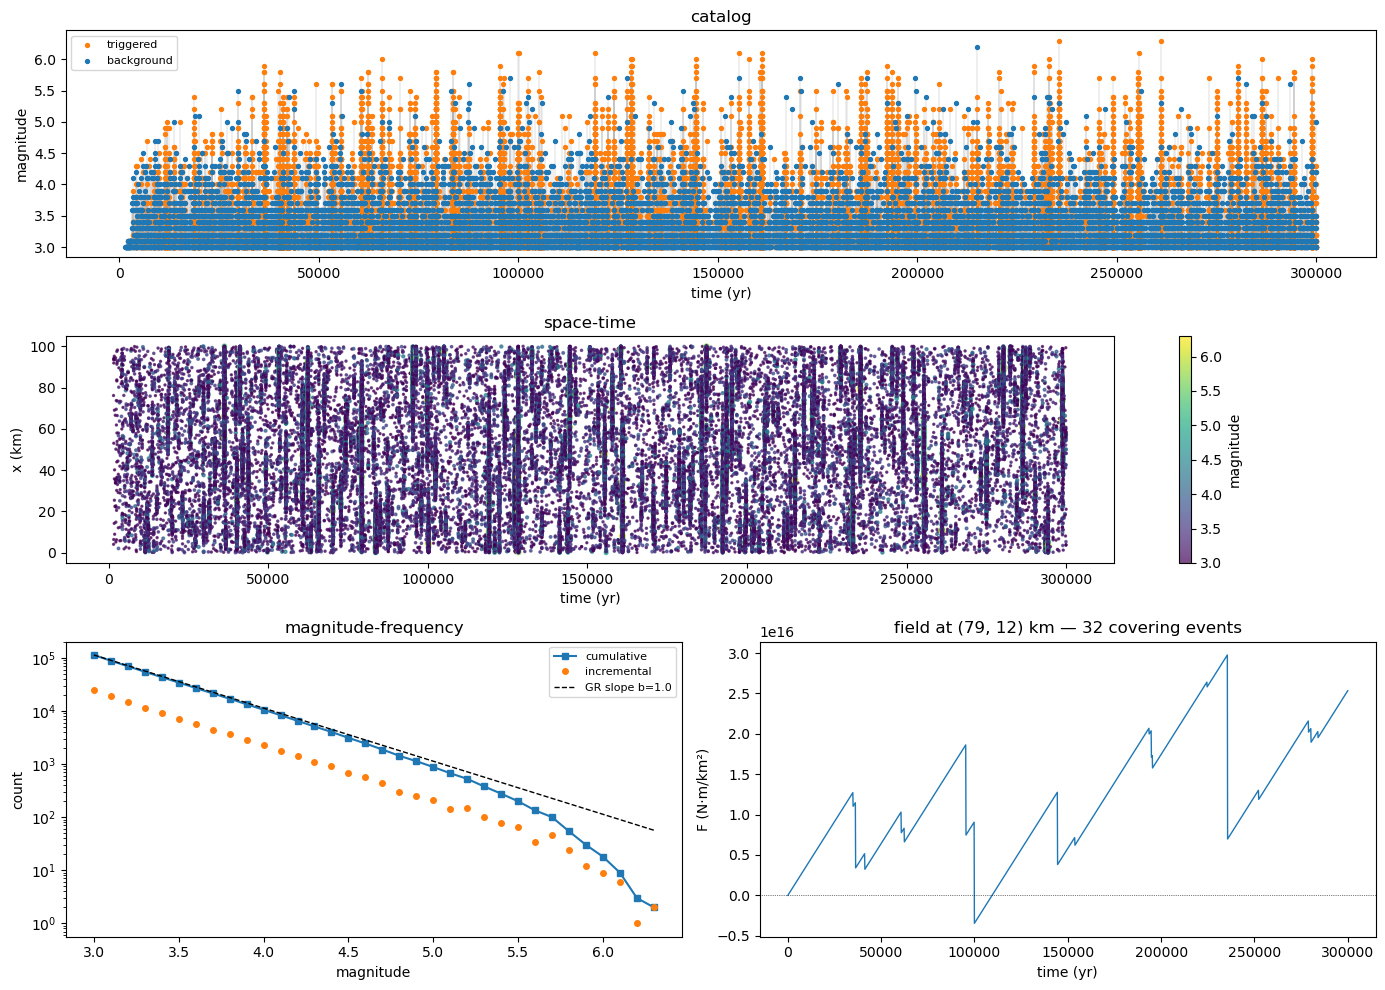

In [53]:
fig = plots.overview(cat)

## Field state and supportable Mmax

Left: the moment density field at the end of the run — rupture-disk "holes" punched by the
largest events into the charged background.

Right: the local Mmax from the supportability scan. Note the **edge effect**: rupture disks
are clipped at the domain boundary, so less moment is enclosed there and the supportable
magnitude drops toward the edges (spec §5.1 — keep the domain larger than the analysis
region).

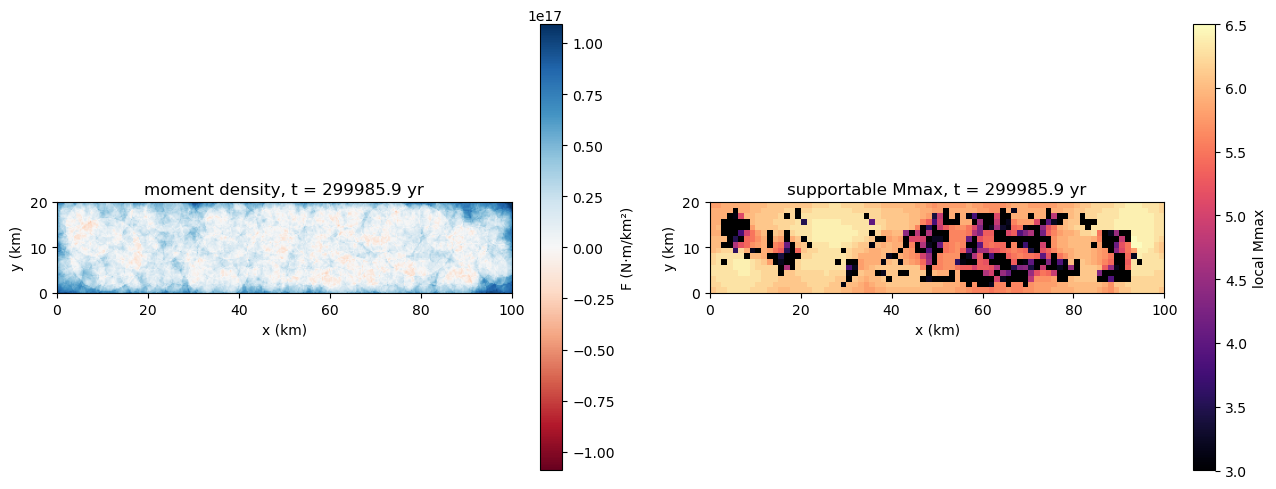

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plots.field_map(cat, ax=axes[0])
plots.mmax_map(cat, coarse=5, ax=axes[1])
fig.tight_layout()

## Epicenters

<Axes: title={'center': 'epicentral density'}, xlabel='x (km)', ylabel='y (km)'>

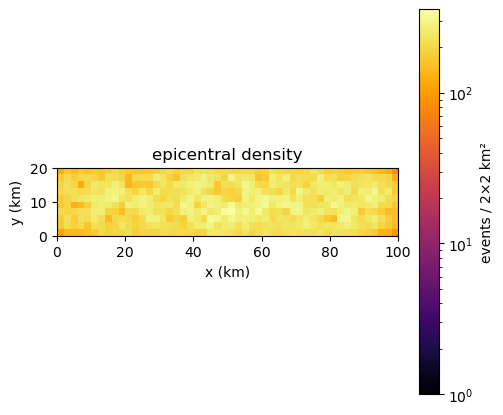

In [55]:
plots.epicenter_density(cat)

(86025670.07583974, 86025770.08583975)

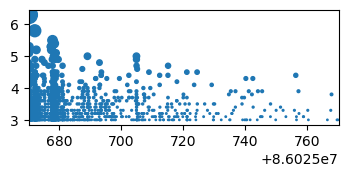

In [56]:
# plot the earthquake sequence associated with the largest event

fig, ax = plt.subplots(figsize=(4, 1.5))

dt_pre = 0.01
dt_post = 100

I = cat.m.argmax()

selected_events = np.where(
    ((cat.t - cat.t[I]) > -dt_pre) & ((cat.t - cat.t[I]) < dt_post)
)[0]

ax.scatter(
    cat.t[selected_events],
    cat.m[selected_events],
    s=10 ** ((cat.m[selected_events] - 3) / 1.5),
)

ax.set_xlim(cat.t[I] - dt_pre, cat.t[I] + dt_post)

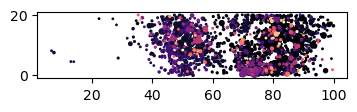

In [60]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(
    cat.x[selected_events],
    cat.y[selected_events],
    s=10 ** ((cat.m[selected_events] - 3) / 1.5),
    c=cat.t[selected_events] - cat.t[I],
    cmap='magma'
)
ax.set_aspect('equal')

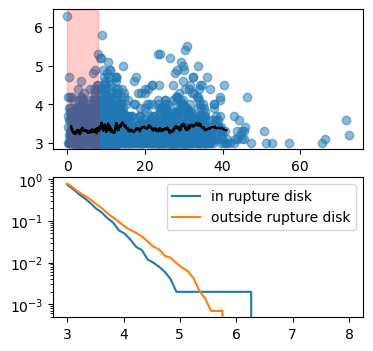

In [61]:
fig, AX = plt.subplots(2, 1, figsize=(4, 4))

ax = AX[0]
r0 = np.array([cat.x[I], cat.y[I]]).reshape(2, 1)
r = np.array([cat.x[selected_events], cat.y[selected_events]])
rupture_radius_km = rupture_radius(cat.m[I], params.a0, params.m_ref)

distance = ((r0 - r) ** 2).sum(axis=0) ** 0.5
ax.scatter(distance, cat.m[selected_events], alpha=0.5)

# plot a moving average of the magnitudes
sorted_events = np.argsort(distance)
sorted_distance = distance[sorted_events]
sorted_m = cat.m[selected_events][sorted_events]

N = 50
moving_average = np.convolve(sorted_m, np.ones(N) / N, mode="valid")
ax.plot(sorted_distance[N // 2 : -N // 2 + 1], moving_average, "k-")
ax.axvspan(0, rupture_radius_km, color="r", alpha=0.2)

ax = AX[1]

M = np.linspace(3, 8, 50)
survival = [
    (sorted_m[sorted_distance < rupture_radius_km] > m).mean()
    for m in M
]


ax.plot(M, survival, label="in rupture disk")

survival = [
    (sorted_m[sorted_distance > rupture_radius_km] > m).mean()
    for m in M
]
ax.plot(M, survival, label="outside rupture disk")
ax.set(
    yscale="log",
)
ax.legend()



## Field evolution animation

`field_animation` replays the catalog's depletions into a fresh grid (exact — same rules as
the simulation) and writes a GIF, so it works on any finished catalog without snapshots.
Blue = charged, white ≈ zero, red = strain deficit; the color scale is fixed across frames.

The window and `n_frames` control the file size — on a fine grid keep frames modest. GIFs are
gitignored, so outputs stay local.

In [ ]:
from IPython.display import Image

# animate the field through the largest event: watch the rupture-disk hole
# get punched into the charged field, then refill by tectonic loading
t_main = cat.t[cat.m.argmax()]

gif_path = plots.field_animation(
    cat,
    path="field_evolution.gif",
    t_start=t_main - 10,   # 20 days before the mainshock
    t_end=t_main + 10,    # 150 days of recovery
    n_frames=240,
    fps=8,
)

Image(gif_path)